In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# EDA

In [2]:
df = pd.read_csv('dataset-comments-yt-after-clustering.csv')

print(f"5 data teratas: \n{df.head()}\n")

print(f"type stiap kolom:  \n{df.info()}\n")

print(f"deskripsi data: \n{df.describe()}\n")

print(f"data null: \n{df.isnull().sum()}\n")

print(f"data NaN: \n{df.isna().sum()}\n")

print(f"data duplikat: \n{df.duplicated().sum()}\n")

print(f"data baris dan kolom: \n{df.shape}")

5 data teratas: 
               author  ...         label
0     @Sophiapandorah  ...  Promosi Judi
1      @rudolfmanik68  ...  Promosi Judi
2        @annamlpride  ...  Promosi Judi
3  @SajjatHossain-u8q  ...  Promosi Judi
4  @SajjatHossain-u8q  ...  Promosi Judi

[5 rows x 8 columns]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1684 entries, 0 to 1683
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   author                   1684 non-null   object
 1   comment                  1684 non-null   object
 2   publishedTimeText        1684 non-null   object
 3   replyCount               1684 non-null   int64 
 4   voteCount                1684 non-null   int64 
 5   comment_after_cleansing  1655 non-null   object
 6   cluster                  1684 non-null   int64 
 7   label                    1684 non-null   object
dtypes: int64(3), object(5)
memory usage: 105.4+ KB
type stiap kolom:  
None



In [3]:
print(df[['comment_after_cleansing']].isnull().sum(),"\n")
df = df.dropna()
print("\n",df.isna().sum())

comment_after_cleansing    29
dtype: int64 


 author                     0
comment                    0
publishedTimeText          0
replyCount                 0
voteCount                  0
comment_after_cleansing    0
cluster                    0
label                      0
dtype: int64


# PREPROCESSING

In [4]:
from sklearn.model_selection import train_test_split

X = df['comment_after_cleansing']
y = df['label']


X_train,X_test, y_train, y_test =  train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y)
print(f"X test: {X_test.shape} | X train: {X_train.shape} ")
print(f"y test: {y_test.shape} | y train: {y_train.shape} ")


X test: (331,) | X train: (1324,) 
y test: (331,) | y train: (1324,) 


# TF-DF

In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
# cek ini
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')
c_v = CountVectorizer()
tfidf = TfidfVectorizer(    ngram_range=(1,10),
    min_df=3,
    max_df=0.9,
    max_features=5000)

X_train_vector_tfidf = tfidf.fit_transform(X_train) 
X_test_vector_tfidf = tfidf.transform(X_test)


X_train_vector_cv = c_v.fit_transform(X_train)

y_train = le.fit_transform(y_train)
y_test = le.fit_transform(y_test)


# print(X_train_vector.toarray(),"\n")
# print(X_train_vector_cv.toarray(),"\n")
# print(X_train_vector.shape)
# print(len(tfidf.vocabulary_))
# print(X_train_vector_cv.shape)
# print(len(c_v.vocabulary_))
# print(y_test)
print(tfidf.fit(X_train).vocabulary_)

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ADVAN\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ADVAN\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\ADVAN\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\ADVAN\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


{'the': np.int64(1118), 'most': np.int64(761), 'usia': np.int64(1201), '2025': np.int64(18), 'experience': np.int64(318), 'cari': np.int64(218), 'alam': np.int64(59), 'mana': np.int64(702), 'kerja': np.int64(571), 'orang': np.int64(839), 'part': np.int64(867), 'kuliah': np.int64(615), 'hancur': np.int64(394), 'rush': np.int64(967), 'terburuburu': np.int64(1106), 'tu': np.int64(1155), 'makan': np.int64(682), 'standar': np.int64(1046), 'society': np.int64(1040), 'tuh': np.int64(1159), '25': np.int64(25), 'uang': np.int64(1169), '20': np.int64(12), 'juta': np.int64(508), 'nama': np.int64(775), '30': np.int64(29), 'rumah': np.int64(965), 'cipta': np.int64(236), 'sukses': np.int64(1055), 'bilang': np.int64(177), 'subjektif': np.int64(1051), 'puas': np.int64(931), 'nominal': np.int64(816), 'saldo': np.int64(980), 'finansial': np.int64(326), 'pilih': np.int64(888), 'of': np.int64(829), 'milik': np.int64(740), 'alternatif': np.int64(70), 'fresh': np.int64(331), 'graduate': np.int64(378), 'nomo

In [6]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report


models = {
    "Naive Bayes" : MultinomialNB(),
    "Random Forest" : RandomForestClassifier(n_estimators=100,
    random_state=42,
    max_depth = 5,
    criterion="gini",
    min_samples_split = 5,
    min_samples_leaf =2,
    class_weight="balanced", #=> jika data imbalance
    n_jobs=-1), # menggunakan seluruh inti (core) CPU agar proses training lebih cepat.),
    "SVM" : SVC(kernel="linear", C=1, random_state=42),
    "Logistik Regressi" : LogisticRegression(max_iter=100),
    "KNN": KNeighborsClassifier(n_neighbors=5)
    }

accuracy = []

for nama, model in models.items():
    model.fit(X_train_vector_tfidf,y_train)

    y_pred = model.predict(X_test_vector_tfidf)
    score = accuracy_score(y_test, y_pred)
    accuracy.append(score)
    
    print(f"nama model: {nama} | score akurasi: {score:.4f}")
    print(classification_report(y_test,y_pred))


nama model: Naive Bayes | score akurasi: 0.9003
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        33
           1       0.90      1.00      0.95       298

    accuracy                           0.90       331
   macro avg       0.45      0.50      0.47       331
weighted avg       0.81      0.90      0.85       331



d:\ANACONDA\envs\LibML\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\ANACONDA\envs\LibML\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\ANACONDA\envs\LibML\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


nama model: Random Forest | score akurasi: 0.9366
              precision    recall  f1-score   support

           0       0.62      0.91      0.74        33
           1       0.99      0.94      0.96       298

    accuracy                           0.94       331
   macro avg       0.81      0.92      0.85       331
weighted avg       0.95      0.94      0.94       331

nama model: SVM | score akurasi: 0.9517
              precision    recall  f1-score   support

           0       0.87      0.61      0.71        33
           1       0.96      0.99      0.97       298

    accuracy                           0.95       331
   macro avg       0.91      0.80      0.84       331
weighted avg       0.95      0.95      0.95       331

nama model: Logistik Regressi | score akurasi: 0.9124
              precision    recall  f1-score   support

           0       0.83      0.15      0.26        33
           1       0.91      1.00      0.95       298

    accuracy                          

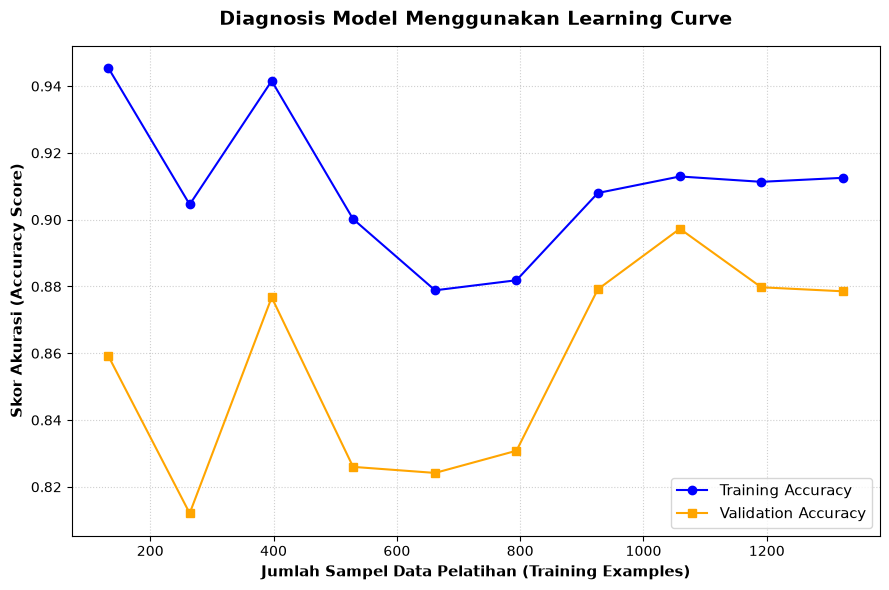

In [13]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import learning_curve
from sklearn.model_selection import StratifiedKFold

# Mengatur agar plot tampil otomatis di dalam notebook Colab
%matplotlib inline

pipeline = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("model", KNeighborsClassifier(n_neighbors=5))
])

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

train_sizes, train_scores, val_scores = learning_curve(
    estimator=pipeline,
    X=df["comment_after_cleansing"],
    y=df["label"],
    cv=cv,
    train_sizes=np.linspace(0.1,1.0,10),
    scoring="accuracy",
    n_jobs=-1
)
# Menghitung rata-rata nilai akurasi dari hasil 5-Fold Cross Validation
train_mean = np.mean(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)

plt.figure(figsize=(9, 6))
plt.plot(train_sizes, train_mean, marker='o', color='blue',  label='Training Accuracy')
plt.plot(train_sizes, val_mean, marker='s', color='orange', label='Validation Accuracy')


plt.title('Diagnosis Model Menggunakan Learning Curve', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Jumlah Sampel Data Pelatihan (Training Examples)', fontsize=11, fontweight='bold')
plt.ylabel('Skor Akurasi (Accuracy Score)', fontsize=11, fontweight='bold')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='lower right', fontsize=11)

plt.tight_layout()
plt.show()

In [8]:
pipeline = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("classifier",  SVC(kernel="linear", C=1))
])

pipeline.fit(
    df["comment_after_cleansing"],
    df["label"]
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('tfidf', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['Bukan PromosiJudi','Promosi Judi']"
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True


In [9]:
import joblib
joblib.dump(pipeline, "spam_classifier.pkl")

['spam_classifier.pkl']

# CV

In [10]:
# from sklearn.feature_extraction.text import CountVectorizer
# from sklearn.preprocessing import LabelEncoder
# # cek ini
# import nltk
# nltk.download('punkt')
# nltk.download('stopwords')
# nltk.download('wordnet')
# nltk.download('punkt_tab')
# le = LabelEncoder()
# c_v = CountVectorizer()

# X_train_vector_cv = c_v.fit_transform(X_train)
# X_test_vector_cv = c_v.transform(X_test)

# y_train = le.fit_transform(y_train)
# y_test = le.fit_transform(y_test)

# # 
# # print(X_train_vector.toarray(),"\n")
# # print(X_train_vector_cv.toarray(),"\n")
# # print(X_train_vector.shape)
# # print(len(tfidf.vocabulary_))
# # print(X_train_vector_cv.shape)
# # print(len(c_v.vocabulary_))
# print(y_test)

In [11]:
# from sklearn.naive_bayes import MultinomialNB
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.svm import SVC
# from sklearn.linear_model import LogisticRegression
# from sklearn.metrics import accuracy_score, classification_report


# models = {
#     "Naive Bayes" : MultinomialNB(),
#     "Random Forest" : RandomForestClassifier(
#     n_estimators=300,
#     random_state=42,
#     max_depth = 10,
#     criterion="gini",
#     min_samples_split = 5,
#     min_samples_leaf =2,
#     class_weight="balanced", #=> jika data imbalance
#     n_jobs=-1), # menggunakan seluruh inti (core) CPU agar proses training lebih cepat.),
#     "SVM" : SVC(kernel="linear", C=1, random_state=42),
#     "Logistik Regressi" : LogisticRegression(    C=1,
#     penalty="l2",
#     max_iter=100    )
#     }

# accuracy = []

# for nama, model in models.items():
#     model.fit(X_train_vector_cv,y_train)

#     y_pred = model.predict(X_test_vector_cv)
#     score = accuracy_score(y_test, y_pred)
#     accuracy.append(score)
    
#     print(f"nama model: {nama} | score akurasi: {score:.2f}")
#     print(classification_report(y_test,y_pred))

In [12]:
# from sklearn.pipeline import Pipeline
# from sklearn.model_selection import learning_curve
# from sklearn.model_selection import StratifiedKFold

# # Mengatur agar plot tampil otomatis di dalam notebook Colab
# %matplotlib inline

# pipeline = Pipeline([
#     ("cv", CountVectorizer()),
#     ("model", MultinomialNB())
# ])

# cv = StratifiedKFold(
#     n_splits=5,
#     shuffle=True,
#     random_state=42
# )

# train_sizes, train_scores, val_scores = learning_curve(
#     estimator=pipeline,
#     X=df["comment_after_cleansing"],
#     y=df["label"],
#     cv=cv,
#     train_sizes=np.linspace(0.1,1.0,10),
#     scoring="accuracy",
#     n_jobs=-1
# )
# # Menghitung rata-rata nilai akurasi dari hasil 5-Fold Cross Validation
# train_mean = np.mean(train_scores, axis=1)
# val_mean = np.mean(val_scores, axis=1)

# plt.figure(figsize=(9, 6))
# plt.plot(train_sizes, train_mean, marker='o', color='blue',  label='Training Accuracy')
# plt.plot(train_sizes, val_mean, marker='s', color='orange', label='Validation Accuracy')


# plt.title('Diagnosis Model Menggunakan Learning Curve', fontsize=14, fontweight='bold', pad=15)
# plt.xlabel('Jumlah Sampel Data Pelatihan (Training Examples)', fontsize=11, fontweight='bold')
# plt.ylabel('Skor Akurasi (Accuracy Score)', fontsize=11, fontweight='bold')
# plt.grid(True, linestyle=':', alpha=0.6)
# plt.legend(loc='lower right', fontsize=11)

# plt.tight_layout()
# plt.show()